# GNN Blockchain Anomaly Detection — Fixed Pipeline
## Elliptic Bitcoin Dataset | 4 Models × 3 Settings | 100 Optuna Trials


In [ ]:
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

install('torch-geometric')
install('kagglehub')
install('optuna')
install('tqdm')
print('All packages installed.')


All packages installed.


In [ ]:
import os, gc, random, inspect, warnings, json, pickle
from typing import Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.nn import (
    GCNConv, GATConv, GATv2Conv, SAGEConv,
    GraphNorm, GINConv, TransformerConv,
)

from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    precision_score, recall_score, f1_score,
    precision_recall_curve, roc_curve,
)

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')


Device: cuda


In [ ]:
DATA_DIR = 'datasets/elliptic'
os.makedirs(DATA_DIR, exist_ok=True)

needed = [
    'elliptic_txs_features.csv',
    'elliptic_txs_edgelist.csv',
    'elliptic_txs_classes.csv',
]

if not all(os.path.exists(os.path.join(DATA_DIR, f)) for f in needed):
    try:
        import kagglehub, shutil
        from pathlib import Path
        src = Path(kagglehub.dataset_download('ellipticco/elliptic-data-set'))
        for name in needed:
            hits = list(src.rglob(name))
            if hits:
                shutil.copy2(hits[0], os.path.join(DATA_DIR, name))
            else:
                raise FileNotFoundError(f'{name} not found')
        print(f'Downloaded to {DATA_DIR}')
    except Exception as e:
        print(f'Auto-download failed: {e}')
        print('Manually place the 3 CSVs in', DATA_DIR)
else:
    print('Dataset already present.')


Using Colab cache for faster access to the 'elliptic-data-set' dataset.
Downloaded to datasets/elliptic


In [ ]:
feat_df  = pd.read_csv(f'{DATA_DIR}/elliptic_txs_features.csv', header=None)
edge_df  = pd.read_csv(f'{DATA_DIR}/elliptic_txs_edgelist.csv')
class_df = pd.read_csv(f'{DATA_DIR}/elliptic_txs_classes.csv')

# column 0 = txId, column 1 = time_step, columns 2-166 = 165 features
feat_df = feat_df.rename(columns={0: 'txId', 1: 'time_step'})

print(f'Nodes: {len(feat_df):,}  |  Edges: {len(edge_df):,}  |  Features: {feat_df.shape[1]-2}')
print('Raw class distribution:')
print(class_df['class'].value_counts().to_string())


Nodes: 203,769  |  Edges: 234,355  |  Features: 165
Raw class distribution:
class
unknown    157205
2           42019
1            4545


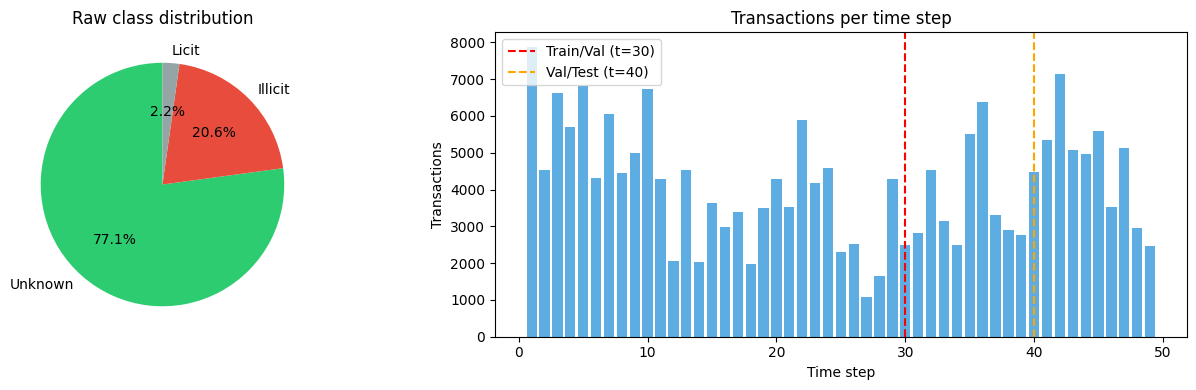

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

lmap = {'1': 'Licit', '2': 'Illicit', 'unknown': 'Unknown'}
class_df['label_name'] = class_df['class'].map(lmap)
counts = class_df['label_name'].value_counts()
axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=['#2ecc71','#e74c3c','#95a5a6'], startangle=90)
axes[0].set_title('Raw class distribution')

tc = feat_df['time_step'].value_counts().sort_index()
axes[1].bar(tc.index, tc.values, color='#3498db', alpha=0.8)
axes[1].axvline(30, color='red',    linestyle='--', label='Train/Val (t=30)')
axes[1].axvline(40, color='orange', linestyle='--', label='Val/Test (t=40)')
axes[1].set_xlabel('Time step'); axes[1].set_ylabel('Transactions')
axes[1].set_title('Transactions per time step'); axes[1].legend()
plt.tight_layout(); plt.show()


In [ ]:
CLASS_MAP = {'unknown': 2, '1': 1, '2': 0}
TIME_SPLITS = [30, 40]

feat_array = feat_df.loc[:, 'time_step':].values
features   = torch.tensor(feat_array, dtype=torch.float)

labels_mapped = class_df['class'].map(CLASS_MAP)
labels        = torch.tensor(labels_mapped.values, dtype=torch.long)


nodes  = feat_df['txId']
map_id = {j: i for i, j in enumerate(nodes)}

# Undirected edges (add reverse + deduplicate + remove self-loops)
edges     = edge_df[['txId1', 'txId2']].copy()
edges_rev = edges.rename(columns={'txId1': 'txId2', 'txId2': 'txId1'})
edges     = pd.concat([edges, edges_rev], ignore_index=True)
edges['txId1'] = edges['txId1'].map(map_id)
edges['txId2'] = edges['txId2'].map(map_id)
edges = edges.dropna().astype(int)
edges = edges[edges['txId1'] != edges['txId2']]
edges = edges.drop_duplicates().reset_index(drop=True)
edge_index = torch.tensor(edges.values.T, dtype=torch.long)

# Temporal masks (known only)
time_step = torch.tensor(feat_df['time_step'].values, dtype=torch.long)
known     = labels != 2

train_mask = (time_step <  TIME_SPLITS[0]) & known
val_mask   = (time_step >= TIME_SPLITS[0]) & (time_step < TIME_SPLITS[1]) & known
test_mask  = (time_step >= TIME_SPLITS[1]) & known

# Drop time_step column → 165 features
x    = features[:, 1:]
data = Data(x=x, y=labels, edge_index=edge_index)
data.train_mask = train_mask
data.val_mask   = val_mask
data.test_mask  = test_mask

# ── Sanity checks ──────────────────────────────────────────────────────────────
assert data.x.shape[1] == 165, f'Expected 165 features, got {data.x.shape[1]}'
assert not torch.logical_and(train_mask, val_mask).any(),  'Train/Val overlap!'
assert not torch.logical_and(train_mask, test_mask).any(), 'Train/Test overlap!'
assert not torch.logical_and(val_mask,   test_mask).any(), 'Val/Test overlap!'

n_illicit_train = (labels[train_mask] == 1).sum().item()
n_licit_train   = (labels[train_mask] == 0).sum().item()
assert n_illicit_train < n_licit_train, \
    f'illicit ({n_illicit_train}) should be minority vs licit ({n_licit_train})'

print('Graph constructed and all sanity checks passed.')
print(f'  Nodes: {data.num_nodes:,}  |  Edges: {data.num_edges:,}  |  Features: {data.num_features}')
print()
for name, mask in [('Train', train_mask), ('Val', val_mask), ('Test', test_mask)]:
    ys = labels[mask]
    ni = (ys == 1).sum().item()  # illicit = label 1
    nl = (ys == 0).sum().item()  # licit   = label 0
    tot = mask.sum().item()
    print(f'  {name}: {tot:,} nodes | illicit={ni} ({ni/tot*100:.1f}%) | licit={nl} ({nl/tot*100:.1f}%)')


Graph constructed and all sanity checks passed.
  Nodes: 203,769  |  Edges: 468,710  |  Features: 165

  Train: 26,381 nodes | illicit=2871 (10.9%) | licit=23510 (89.1%)
  Val: 8,999 nodes | illicit=1038 (11.5%) | licit=7961 (88.5%)
  Test: 11,184 nodes | illicit=636 (5.7%) | licit=10548 (94.3%)


In [ ]:
# ── Weighted CrossEntropyLoss ──────────────────────────────────────────────
# illicit = label 1 = minority → upweighted
# licit   = label 0 = majority → downweighted
y_train   = labels[train_mask]
n_illicit = (y_train == 1).sum().item()
n_licit   = (y_train == 0).sum().item()
n_total   = n_illicit + n_licit

w_licit   = n_total / (2 * n_licit)
w_illicit = n_total / (2 * n_illicit)
class_weights = torch.tensor([w_licit, w_illicit])

assert class_weights[1] > class_weights[0], \
    'illicit weight must be higher than licit weight'

print(f'Class weights:')
print(f'  licit   (label 0): {w_licit:.4f}  (majority, downweighted)')
print(f'  illicit (label 1): {w_illicit:.4f}  (minority, upweighted)')
print(f'  Ratio illicit/licit: {w_illicit/w_licit:.2f}x')


Class weights:
  licit   (label 0): 0.5611  (majority, downweighted)
  illicit (label 1): 4.5944  (minority, upweighted)
  Ratio illicit/licit: 8.19x


In [ ]:
# ════════════════════════════════════════════════════════════════════════
# MODEL DEFINITIONS
# ════════════════════════════════════════════════════════════════════════

def _init_out(out, init_mode):
    """Shared output layer initialisation for all models."""
    if out is None: return
    if init_mode == 'xavier':
        nn.init.xavier_uniform_(out.weight)
        nn.init.zeros_(out.bias)
    elif init_mode == 'default':
        out.reset_parameters()


class GCN(nn.Module):
    def __init__(self, in_channels, hidden_dim, embedding_dim, output_dim=2,
                 num_layers=2, dropout=0.5, graphnorm=False, init_mode='xavier'):
        super().__init__()
        assert num_layers >= 1
        self.convs = nn.ModuleList()
        self.gns   = nn.ModuleList() if graphnorm else None
        self.graphnorm = graphnorm
        self.dropout   = dropout
        self.init_mode = init_mode

        dims = [in_channels] + [hidden_dim]*(num_layers-1) + [embedding_dim]
        for i in range(num_layers):
            # cached=False: no stale cache across Optuna trials
            self.convs.append(GCNConv(dims[i], dims[i+1], cached=False))
            if graphnorm and i < num_layers - 1:
                self.gns.append(GraphNorm(dims[i+1]))

        self.out = nn.Linear(embedding_dim, output_dim)
        self._init_weights()

    def _init_weights(self):
        for conv in self.convs: conv.reset_parameters()
        if self.graphnorm:
            for gn in self.gns: gn.reset_parameters()
        _init_out(self.out, self.init_mode)

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = F.relu(x)
                if self.graphnorm: x = self.gns[i](x)
                x = F.dropout(x, p=self.dropout, training=self.training)
        return self.out(x)


class GAT(nn.Module):
    def __init__(self, in_channels, hidden_dim, embedding_dim, output_dim=2,
                 num_layers=2, dropout=0.5, graphnorm=False, init_mode='xavier',
                 n_heads=4, negative_slope=0.2):
        super().__init__()
        assert num_layers >= 1
        self.convs = nn.ModuleList()
        self.gns   = nn.ModuleList() if graphnorm else None
        self.graphnorm = graphnorm
        self.dropout   = dropout
        self.init_mode = init_mode

        if num_layers == 1:

            self.convs.append(GATConv(in_channels, embedding_dim,
                heads=1, concat=False, dropout=0.0,
                negative_slope=negative_slope))
        else:
            self.convs.append(GATConv(in_channels, hidden_dim,
                heads=n_heads, concat=True, dropout=0.0,
                negative_slope=negative_slope))
            if graphnorm: self.gns.append(GraphNorm(hidden_dim * n_heads))
            for _ in range(num_layers - 2):
                self.convs.append(GATConv(hidden_dim * n_heads, hidden_dim,
                    heads=n_heads, concat=True, dropout=0.0,
                    negative_slope=negative_slope))
                if graphnorm: self.gns.append(GraphNorm(hidden_dim * n_heads))
            self.convs.append(GATConv(hidden_dim * n_heads, embedding_dim,
                heads=1, concat=False, dropout=0.0,
                negative_slope=negative_slope))

        self.out = nn.Linear(embedding_dim, output_dim)
        self._init_weights()

    def _init_weights(self):
        for conv in self.convs: conv.reset_parameters()
        if self.graphnorm:
            for gn in self.gns: gn.reset_parameters()
        _init_out(self.out, self.init_mode)

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = F.relu(x)
                if self.graphnorm: x = self.gns[i](x)
                x = F.dropout(x, p=self.dropout, training=self.training)
        return self.out(x)


class GATv2(nn.Module):
    def __init__(self, in_channels, hidden_dim, embedding_dim, output_dim=2,
                 num_layers=2, dropout=0.5, graphnorm=False, init_mode='xavier',
                 n_heads=4, negative_slope=0.2):
        super().__init__()
        assert num_layers >= 1
        self.convs = nn.ModuleList()
        self.gns   = nn.ModuleList() if graphnorm else None
        self.graphnorm = graphnorm
        self.dropout   = dropout
        self.init_mode = init_mode

        if num_layers == 1:
            self.convs.append(GATv2Conv(in_channels, embedding_dim,
                heads=1, concat=False, dropout=0.0,
                negative_slope=negative_slope))
        else:
            self.convs.append(GATv2Conv(in_channels, hidden_dim,
                heads=n_heads, concat=True, dropout=0.0,
                negative_slope=negative_slope))
            if graphnorm: self.gns.append(GraphNorm(hidden_dim * n_heads))
            for _ in range(num_layers - 2):
                self.convs.append(GATv2Conv(hidden_dim * n_heads, hidden_dim,
                    heads=n_heads, concat=True, dropout=0.0,
                    negative_slope=negative_slope))
                if graphnorm: self.gns.append(GraphNorm(hidden_dim * n_heads))
            self.convs.append(GATv2Conv(hidden_dim * n_heads, embedding_dim,
                heads=1, concat=False, dropout=0.0,
                negative_slope=negative_slope))

        self.out = nn.Linear(embedding_dim, output_dim)
        self._init_weights()

    def _init_weights(self):
        for conv in self.convs: conv.reset_parameters()
        if self.graphnorm:
            for gn in self.gns: gn.reset_parameters()
        _init_out(self.out, self.init_mode)

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = F.relu(x)
                if self.graphnorm: x = self.gns[i](x)
                x = F.dropout(x, p=self.dropout, training=self.training)
        return self.out(x)


class SAGE(nn.Module):
    def __init__(self, in_channels, hidden_dim, embedding_dim, output_dim=2,
                 num_layers=2, dropout=0.5, graphnorm=False, init_mode='xavier',
                 aggregator='mean'):
        super().__init__()
        assert num_layers >= 1
        self.convs = nn.ModuleList()
        self.gns   = nn.ModuleList() if graphnorm else None
        self.graphnorm = graphnorm
        self.dropout   = dropout
        self.init_mode = init_mode

        dims = [in_channels] + [hidden_dim]*(num_layers-1) + [embedding_dim]
        for i in range(num_layers):
            self.convs.append(SAGEConv(dims[i], dims[i+1], aggr=aggregator))
            if graphnorm and i < num_layers - 1:
                self.gns.append(GraphNorm(dims[i+1]))

        self.out = nn.Linear(embedding_dim, output_dim)
        self._init_weights()

    def _init_weights(self):
        for conv in self.convs: conv.reset_parameters()
        if self.graphnorm:
            for gn in self.gns: gn.reset_parameters()
        _init_out(self.out, self.init_mode)

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = F.relu(x)
                if self.graphnorm: x = self.gns[i](x)
                x = F.dropout(x, p=self.dropout, training=self.training)
        return self.out(x)


class GIN(nn.Module):
    def __init__(self, in_channels, hidden_dim, embedding_dim, output_dim=2,
                 num_layers=2, dropout=0.5, graphnorm=False, init_mode='xavier'):
        super().__init__()
        assert num_layers >= 1
        self.convs = nn.ModuleList()
        self.gns   = nn.ModuleList() if graphnorm else None
        self.graphnorm = graphnorm
        self.dropout   = dropout
        self.init_mode = init_mode

        def _mlp(in_ch, out_ch):
            if graphnorm:
                return nn.Sequential(
                    nn.Linear(in_ch, out_ch),
                    nn.ReLU(),
                    nn.Linear(out_ch, out_ch),
                )
            else:
                return nn.Sequential(
                    nn.Linear(in_ch, out_ch),
                    nn.BatchNorm1d(out_ch),
                    nn.ReLU(),
                    nn.Linear(out_ch, out_ch),
                )

        if num_layers == 1:
            self.convs.append(GINConv(_mlp(in_channels, embedding_dim), train_eps=False))
        else:
            self.convs.append(GINConv(_mlp(in_channels, hidden_dim), train_eps=False))
            if graphnorm: self.gns.append(GraphNorm(hidden_dim))
            for _ in range(num_layers - 2):
                self.convs.append(GINConv(_mlp(hidden_dim, hidden_dim), train_eps=False))
                if graphnorm: self.gns.append(GraphNorm(hidden_dim))
            self.convs.append(GINConv(_mlp(hidden_dim, embedding_dim), train_eps=False))

        self.out = nn.Linear(embedding_dim, output_dim)
        self._init_weights()

    def _init_weights(self):
        for conv in self.convs:
            for m in conv.nn.modules():
                if hasattr(m, 'reset_parameters'):
                    m.reset_parameters()
        if self.graphnorm:
            for gn in self.gns: gn.reset_parameters()
        _init_out(self.out, self.init_mode)

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = F.relu(x)
                if self.graphnorm: x = self.gns[i](x)
                x = F.dropout(x, p=self.dropout, training=self.training)
        return self.out(x)


class GraphTransformer(nn.Module):
    def __init__(self, in_channels, hidden_dim, embedding_dim, output_dim=2,
                 num_layers=2, dropout=0.5, graphnorm=False, init_mode='xavier',
                 n_heads=4):
        super().__init__()
        assert num_layers >= 1
        self.convs = nn.ModuleList()
        self.gns   = nn.ModuleList() if graphnorm else None
        self.graphnorm = graphnorm
        self.dropout   = dropout
        self.init_mode = init_mode
        if num_layers == 1:
            self.convs.append(TransformerConv(
                in_channels, embedding_dim, heads=1, concat=False,
                dropout=0.0, beta=True))
        else:
            self.convs.append(TransformerConv(
                in_channels, hidden_dim, heads=n_heads, concat=True,
                dropout=0.0, beta=True))
            if graphnorm: self.gns.append(GraphNorm(hidden_dim * n_heads))
            for _ in range(num_layers - 2):
                self.convs.append(TransformerConv(
                    hidden_dim * n_heads, hidden_dim, heads=n_heads, concat=True,
                    dropout=0.0, beta=True))
                if graphnorm: self.gns.append(GraphNorm(hidden_dim * n_heads))
            self.convs.append(TransformerConv(
                hidden_dim * n_heads, embedding_dim, heads=1, concat=False,
                dropout=0.0, beta=True))

        self.out = nn.Linear(embedding_dim, output_dim)
        self._init_weights()

    def _init_weights(self):
        for conv in self.convs: conv.reset_parameters()
        if self.graphnorm:
            for gn in self.gns: gn.reset_parameters()
        _init_out(self.out, self.init_mode)

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                if self.graphnorm: x = self.gns[i](x)
                x = F.dropout(x, p=self.dropout, training=self.training)
        return self.out(x)


MODEL_REGISTRY = {
    'GCN':    GCN,
    'GAT':    GAT,
    'GATv2':  GATv2,
    'SAGE':   SAGE,
    'GIN':    GIN,
    'GTRANS': GraphTransformer,
}

print('Models defined:', list(MODEL_REGISTRY.keys()))


Models defined: ['GCN', 'GAT', 'GATv2', 'SAGE', 'GIN', 'GTRANS']


In [ ]:
# ════════════════════════════════════════════════════════════════════════
# TRAINING & EVALUATION UTILITIES
# ════════════════════════════════════════════════════════════════════════

def clear_gpu_memory():
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()


def train_and_evaluate(model, data, train_mask, val_mask, test_mask,
                       lr, n_epochs, weight_decay, device, class_weights,
                       verbose=False):


    model      = model.to(device)
    data       = data.to(device)
    train_mask = train_mask.to(device)

    if val_mask is not None and test_mask is not None:
        assert not torch.logical_and(
            val_mask.bool().to(device), test_mask.bool().to(device)).any(), \
            'val_mask and test_mask must be disjoint'

    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_losses, val_scores, val_losses = [], [], []
    best_val_auprc   = 0.0
    best_model_state = None

    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        out  = model(data.x, data.edge_index)
        loss = criterion(out[train_mask], data.y[train_mask])
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            out = model(data.x, data.edge_index)
            if val_mask is not None and val_mask.to(device).sum() > 0:
                vm       = val_mask.to(device)
                logits_v = out[vm]
                probs_v  = logits_v.softmax(dim=1)
                y_v      = data.y[vm]
                v_loss   = criterion(logits_v, y_v).item()
                val_losses.append(v_loss)
                try:
                    # probs[:, 1] = illicit probability (positive class)
                    ap = average_precision_score(
                        y_v.cpu().numpy(), probs_v[:, 1].cpu().numpy())
                except Exception:
                    ap = 0.0
                val_scores.append(ap)
                if ap > best_val_auprc:
                    best_val_auprc   = ap
                    best_model_state = {k: v.cpu().clone()
                                        for k, v in model.state_dict().items()}
            else:
                val_scores.append(None)
                val_losses.append(None)

        if verbose and (epoch + 1) % 50 == 0:
            vs = val_scores[-1]
            if vs is not None:
                print(f'  Epoch {epoch+1:3d}/{n_epochs} | '
                      f'Loss: {loss.item():.4f} | Val AUPRC: {vs:.4f}')
            else:
                print(f'  Epoch {epoch+1:3d}/{n_epochs} | Loss: {loss.item():.4f}')

    # Restore best-epoch weights
    if best_model_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})

    # Single-pass test evaluation with restored best weights
    model.eval()
    with torch.no_grad():
        out    = model(data.x, data.edge_index)
        tm     = test_mask.to(device)
        probs  = out[tm].softmax(dim=1)
        y_test = data.y[tm].cpu().numpy()
        p_test = probs[:, 1].cpu().numpy()   # illicit probability
        test_auprc = average_precision_score(y_test, p_test)
        test_auroc = roc_auc_score(y_test, p_test)

    return {
        'model':          model,
        'train_losses':   train_losses,
        'val_scores':     val_scores,
        'val_losses':     val_losses,
        'best_val_auprc': best_val_auprc,
        'test_auprc':     test_auprc,
        'test_auroc':     test_auroc,
        'test_probs':     p_test,
        'test_labels':    y_test,
    }


def evaluate_test(model, data, test_mask, device,
                  percentile_q_list=[90, 99, 99.9]):
    """Single-pass full test set evaluation. probs[:, 1] = illicit probability."""
    model.eval()
    with torch.no_grad():
        out    = model(data.x.to(device), data.edge_index.to(device))
        tm     = test_mask.to(device)
        probs  = out[tm].softmax(dim=1)
        y_test = data.y[tm].cpu().numpy()
        p_test = probs[:, 1].cpu().numpy()

    auroc = roc_auc_score(y_test, p_test)
    auprc = average_precision_score(y_test, p_test)
    prec_c, rec_c, _ = precision_recall_curve(y_test, p_test)

    res = {
        'test_auroc':  auroc,
        'test_auprc':  auprc,
        'test_probs':  p_test,
        'test_labels': y_test,
        'pr_prec':     prec_c,
        'pr_recall':   rec_c,
    }
    for q in percentile_q_list:
        cutoff = np.percentile(p_test, q)
        y_hard = (p_test >= cutoff).astype(int)
        res[f'precision_at_{q}'] = precision_score(y_test, y_hard, zero_division=0)
        res[f'recall_at_{q}']    = recall_score(y_test, y_hard,    zero_division=0)
        res[f'f1_at_{q}']        = f1_score(y_test, y_hard,        zero_division=0)
    return res


def build_model(model_name, in_channels, hparams, graphnorm, init_mode):
    cls    = MODEL_REGISTRY[model_name]
    kwargs = {
        'in_channels':   in_channels,
        'hidden_dim':    hparams['hidden_dim'],
        'embedding_dim': hparams['embedding_dim'],
        'output_dim':    2,
        'num_layers':    hparams['num_layers'],
        'dropout':       hparams['dropout'],
        'graphnorm':     graphnorm,
        'init_mode':     init_mode,
    }
    if model_name == 'SAGE':
        kwargs['aggregator'] = hparams.get('aggregator', 'mean')
    if model_name in ('GTRANS', 'GAT', 'GATv2'):
        kwargs['n_heads'] = hparams.get('n_heads', 4)
    sig    = inspect.signature(cls.__init__)
    kwargs = {k: v for k, v in kwargs.items() if k in sig.parameters}
    return cls(**kwargs)


print('Utilities defined.')


Utilities defined.


In [ ]:
# ════════════════════════════════════════════════════════════════════════
# EXPERIMENT CONFIGURATION
# ════════════════════════════════════════════════════════════════════════

N_TRIALS = 30

EXPERIMENT_SETTINGS = {
    'baseline':         {'graphnorm': False, 'init_mode': 'default'},
    'xavier_only':      {'graphnorm': False, 'init_mode': 'xavier'},
    'graphnorm_xavier': {'graphnorm': True,  'init_mode': 'xavier'},
}
MODEL_NAMES = ['GCN', 'GAT', 'GATv2', 'SAGE']
WEIGHT_DECAY_DEFAULT = 5e-4

# Move data to device once
data_device = data.to(DEVICE)
train_mask_d = data.train_mask.to(DEVICE)
val_mask_d   = data.val_mask.to(DEVICE)
test_mask_d  = data.test_mask.to(DEVICE)

all_results = {}

COLORS = {
    'GCN': '#1f77b4', 'GAT': '#ff7f0e', 'GATv2': '#17becf',
    'SAGE': '#2ca02c',
}

os.makedirs('checkpoints', exist_ok=True)
os.makedirs('results_csv', exist_ok=True)


def run_experiment(model_name, setting_name, setting_config):
    """Run one full Optuna study for (model_name, setting_name), then
    retrain the final model once from scratch on the best hyperparameters.
    Saves checkpoint and stores metrics in all_results.
    """
    graphnorm = setting_config['graphnorm']
    init_mode = setting_config['init_mode']

    print('\n' + '='*60)
    print(f'Setting : {setting_name} (graphnorm={graphnorm}, init={init_mode})')
    print(f'Model   : {model_name}')
    print('='*60)
    clear_gpu_memory()

    # ── Optuna objective ──────────────────────────────────────────────────────
    def objective(trial):
        hparams = {
            'hidden_dim':    trial.suggest_int('hidden_dim',    128, 256),
            'embedding_dim': trial.suggest_int('embedding_dim',  64, 128),
            'num_layers':    trial.suggest_int('num_layers',       1,   3),
            'dropout':       trial.suggest_float('dropout', 0.08, 0.64, log=True),
        }
        if model_name == 'SAGE':
            hparams['aggregator'] = trial.suggest_categorical(
                'aggregator', ['mean', 'max'])
        if model_name in ('GTRANS', 'GAT', 'GATv2'):
            hparams['n_heads'] = 4

        lr           = trial.suggest_float('lr',           2e-6, 1e-3, log=True)
        n_epochs     = trial.suggest_int('n_epochs',        128, 512)
        weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)

        model = build_model(model_name, data.num_features,
                            hparams, graphnorm, init_mode)
        try:
            result = train_and_evaluate(
                model, data_device, train_mask_d, val_mask_d, test_mask_d,
                lr=lr, n_epochs=n_epochs, weight_decay=weight_decay,
                device=DEVICE, class_weights=class_weights,
            )
        except (RuntimeError, Exception) as e:
            if 'out of memory' in str(e).lower() or isinstance(e, torch.cuda.OutOfMemoryError if hasattr(torch.cuda, 'OutOfMemoryError') else RuntimeError):
                del model; clear_gpu_memory()
                raise optuna.TrialPruned(f'OOM trial {trial.number}')
            del model; clear_gpu_memory()
            raise optuna.TrialPruned(f'Error trial {trial.number}: {e}')

        score = result['best_val_auprc']
        trial.set_user_attr('test_auprc', result['test_auprc'])
        trial.set_user_attr('test_auroc', result['test_auroc'])
        trial.set_user_attr('history', {
            'train_loss': result['train_losses'],
            'val_score':  result['val_scores'],
            'val_loss':   result['val_losses'],
        })
        del model, result; clear_gpu_memory()
        return score

    # ── Run Optuna ────────────────────────────────────────────────────────────
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=SEED),
    )
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    completed = [t for t in study.trials
                 if t.state == optuna.trial.TrialState.COMPLETE]
    if not completed:
        print(f'   All trials failed. Skipping {model_name}/{setting_name}.')
        return

    best = study.best_trial
    print(f'   Best val AUPRC (Optuna search): {best.value:.4f}')

    # ── Extract best hyperparameters ──────────────────────────────────────────
    best_hparams  = dict(best.params)
    lr_best       = best_hparams.pop('lr')
    n_epochs_best = best_hparams.pop('n_epochs')
    wd_best       = best_hparams.pop('weight_decay', WEIGHT_DECAY_DEFAULT)

    # ── Retrain final model from scratch on best hparams ──────────────────────
    final_model = build_model(model_name, data.num_features,
                              best_hparams, graphnorm, init_mode)
    result_final = train_and_evaluate(
        final_model, data_device, train_mask_d, val_mask_d, test_mask_d,
        lr=lr_best, n_epochs=n_epochs_best, weight_decay=wd_best,
        device=DEVICE, class_weights=class_weights, verbose=True,
    )

    # ── Final single-pass test evaluation ────────────────────────────────────
    test_eval = evaluate_test(
        result_final['model'], data_device, test_mask_d, DEVICE,
        percentile_q_list=[90, 99, 99.9],
    )

    # ── Checkpoint ────────────────────────────────────────────────────────────
    ckpt_path = f'checkpoints/{model_name}_{setting_name}_best.pt'
    torch.save({
        'model_name':   model_name,
        'setting_name': setting_name,
        'state_dict':   result_final['model'].cpu().state_dict(),
        'hparams':      best_hparams,
        'lr':           lr_best,
        'n_epochs':     n_epochs_best,
        'weight_decay': wd_best,
        'graphnorm':    graphnorm,
        'init_mode':    init_mode,
        'val_auprc':    result_final['best_val_auprc'],
        'test_auprc':   test_eval['test_auprc'],
        'test_auroc':   test_eval['test_auroc'],
    }, ckpt_path)

    # ── Store in all_results ──────────────────────────────────────────────────
    key = (setting_name, model_name)
    all_results[key] = {
        'best_params':       {**best_hparams, 'lr': lr_best,
                               'n_epochs': n_epochs_best, 'weight_decay': wd_best},
        'val_auprc':         result_final['best_val_auprc'],
        'test_auprc':        test_eval['test_auprc'],
        'test_auroc':        test_eval['test_auroc'],
        'f1_at_90':          test_eval['f1_at_90'],
        'f1_at_99':          test_eval['f1_at_99'],
        'f1_at_99.9':        test_eval.get('f1_at_99.9', 0.0),
        'precision_at_90':   test_eval['precision_at_90'],
        'recall_at_90':      test_eval['recall_at_90'],
        'test_probs':        test_eval['test_probs'],
        'test_labels':       test_eval['test_labels'],
        'pr_prec':           test_eval['pr_prec'],
        'pr_recall':         test_eval['pr_recall'],
        'train_losses':      result_final['train_losses'],
        'val_scores':        result_final['val_scores'],
        'val_losses':        result_final['val_losses'],
        'optuna_history':    best.user_attrs.get('history', {}),
    }

    print(f'   Checkpoint : {ckpt_path}')
    print(f'   Final model — Val AUPRC  : {result_final["best_val_auprc"]:.4f}')
    print(f'   Final model — Test AUROC : {test_eval["test_auroc"]:.4f}')
    print(f'   Final model — Test AUPRC : {test_eval["test_auprc"]:.4f}')
    print(f'   Final model — F1@90      : {test_eval["f1_at_90"]:.4f}')
    print(f'   Final model — F1@99      : {test_eval["f1_at_99"]:.4f}')

    del final_model, result_final; clear_gpu_memory()


print(f'Experiments: {len(EXPERIMENT_SETTINGS)} settings × {len(MODEL_NAMES)} models = '
      f'{len(EXPERIMENT_SETTINGS)*len(MODEL_NAMES)} total')
print(f'N_TRIALS = {N_TRIALS}')


Experiments: 3 settings × 4 models = 12 total
N_TRIALS = 30


In [ ]:
run_experiment('GCN', 'baseline', EXPERIMENT_SETTINGS['baseline'])


Setting : baseline (graphnorm=False, init=default)
Model   : GCN


  0%|          | 0/30 [00:00<?, ?it/s]

   Best val AUPRC (Optuna search): 0.7836
  Epoch  50/293 | Loss: 0.2327 | Val AUPRC: 0.6297
  Epoch 100/293 | Loss: 0.1781 | Val AUPRC: 0.6204
  Epoch 150/293 | Loss: 0.1412 | Val AUPRC: 0.6617
  Epoch 200/293 | Loss: 0.1186 | Val AUPRC: 0.7296
  Epoch 250/293 | Loss: 0.1007 | Val AUPRC: 0.7573
   Checkpoint : checkpoints/GCN_baseline_best.pt
   Final model — Val AUPRC  : 0.7762
   Final model — Test AUROC : 0.8114
   Final model — Test AUPRC : 0.3150
   Final model — F1@90      : 0.3897
   Final model — F1@99      : 0.1070


In [ ]:
run_experiment('GAT', 'baseline', EXPERIMENT_SETTINGS['baseline'])


Setting : baseline (graphnorm=False, init=default)
Model   : GAT


  0%|          | 0/30 [00:00<?, ?it/s]

   Best val AUPRC (Optuna search): 0.8856
  Epoch  50/341 | Loss: 0.1405 | Val AUPRC: 0.7881
  Epoch 100/341 | Loss: 0.0689 | Val AUPRC: 0.8579
  Epoch 150/341 | Loss: 0.0358 | Val AUPRC: 0.8708
  Epoch 200/341 | Loss: 0.0241 | Val AUPRC: 0.8592
  Epoch 250/341 | Loss: 0.0182 | Val AUPRC: 0.8559
  Epoch 300/341 | Loss: 0.0160 | Val AUPRC: 0.8616
   Checkpoint : checkpoints/GAT_baseline_best.pt
   Final model — Val AUPRC  : 0.8721
   Final model — Test AUROC : 0.7929
   Final model — Test AUPRC : 0.3303
   Final model — F1@90      : 0.4057
   Final model — F1@99      : 0.1578


In [ ]:
run_experiment('GATv2', 'baseline', EXPERIMENT_SETTINGS['baseline'])


Setting : baseline (graphnorm=False, init=default)
Model   : GATv2


  0%|          | 0/30 [00:00<?, ?it/s]

   Best val AUPRC (Optuna search): 0.9064
  Epoch  50/343 | Loss: 0.1427 | Val AUPRC: 0.8093
  Epoch 100/343 | Loss: 0.0665 | Val AUPRC: 0.8893
  Epoch 150/343 | Loss: 0.0354 | Val AUPRC: 0.8942
  Epoch 200/343 | Loss: 0.0224 | Val AUPRC: 0.8710
  Epoch 250/343 | Loss: 0.0168 | Val AUPRC: 0.8715
  Epoch 300/343 | Loss: 0.0129 | Val AUPRC: 0.8735
   Checkpoint : checkpoints/GATv2_baseline_best.pt
   Final model — Val AUPRC  : 0.8945
   Final model — Test AUROC : 0.8189
   Final model — Test AUPRC : 0.4994
   Final model — F1@90      : 0.3966
   Final model — F1@99      : 0.2781


In [ ]:
run_experiment('SAGE', 'baseline', EXPERIMENT_SETTINGS['baseline'])


Setting : baseline (graphnorm=False, init=default)
Model   : SAGE


  0%|          | 0/30 [00:00<?, ?it/s]

   Best val AUPRC (Optuna search): 0.8646
  Epoch  50/262 | Loss: 0.1471 | Val AUPRC: 0.8290
  Epoch 100/262 | Loss: 0.0596 | Val AUPRC: 0.8550
  Epoch 150/262 | Loss: 0.0244 | Val AUPRC: 0.8411
  Epoch 200/262 | Loss: 0.0123 | Val AUPRC: 0.8209
  Epoch 250/262 | Loss: 0.0079 | Val AUPRC: 0.8253
   Checkpoint : checkpoints/SAGE_baseline_best.pt
   Final model — Val AUPRC  : 0.8593
   Final model — Test AUROC : 0.8338
   Final model — Test AUPRC : 0.5033
   Final model — F1@90      : 0.4114
   Final model — F1@99      : 0.2807


In [ ]:
run_experiment('GCN', 'xavier_only', EXPERIMENT_SETTINGS['xavier_only'])


Setting : xavier_only (graphnorm=False, init=xavier)
Model   : GCN


  0%|          | 0/30 [00:00<?, ?it/s]

   Best val AUPRC (Optuna search): 0.8045
  Epoch  50/456 | Loss: 0.2200 | Val AUPRC: 0.6205
  Epoch 100/456 | Loss: 0.1666 | Val AUPRC: 0.6144
  Epoch 150/456 | Loss: 0.1331 | Val AUPRC: 0.6515
  Epoch 200/456 | Loss: 0.1045 | Val AUPRC: 0.7117
  Epoch 250/456 | Loss: 0.0857 | Val AUPRC: 0.7397
  Epoch 300/456 | Loss: 0.0687 | Val AUPRC: 0.7613
  Epoch 350/456 | Loss: 0.0577 | Val AUPRC: 0.7740
  Epoch 400/456 | Loss: 0.0493 | Val AUPRC: 0.7750
  Epoch 450/456 | Loss: 0.0416 | Val AUPRC: 0.7808
   Checkpoint : checkpoints/GCN_xavier_only_best.pt
   Final model — Val AUPRC  : 0.7821
   Final model — Test AUROC : 0.8144
   Final model — Test AUPRC : 0.2924
   Final model — F1@90      : 0.3772
   Final model — F1@99      : 0.0989


In [ ]:
run_experiment('GAT', 'xavier_only', EXPERIMENT_SETTINGS['xavier_only'])


Setting : xavier_only (graphnorm=False, init=xavier)
Model   : GAT


  0%|          | 0/30 [00:00<?, ?it/s]

   Best val AUPRC (Optuna search): 0.8865
  Epoch  50/415 | Loss: 0.1762 | Val AUPRC: 0.7911
  Epoch 100/415 | Loss: 0.1114 | Val AUPRC: 0.8626
  Epoch 150/415 | Loss: 0.0740 | Val AUPRC: 0.8739
  Epoch 200/415 | Loss: 0.0547 | Val AUPRC: 0.8652
  Epoch 250/415 | Loss: 0.0406 | Val AUPRC: 0.8620
  Epoch 300/415 | Loss: 0.0347 | Val AUPRC: 0.8685
  Epoch 350/415 | Loss: 0.0306 | Val AUPRC: 0.8565
  Epoch 400/415 | Loss: 0.0255 | Val AUPRC: 0.8735
   Checkpoint : checkpoints/GAT_xavier_only_best.pt
   Final model — Val AUPRC  : 0.8775
   Final model — Test AUROC : 0.8122
   Final model — Test AUPRC : 0.4784
   Final model — F1@90      : 0.4046
   Final model — F1@99      : 0.2647


In [ ]:
run_experiment('GATv2', 'xavier_only', EXPERIMENT_SETTINGS['xavier_only'])


Setting : xavier_only (graphnorm=False, init=xavier)
Model   : GATv2


  0%|          | 0/30 [00:00<?, ?it/s]

   Best val AUPRC (Optuna search): 0.8901
  Epoch  50/337 | Loss: 0.1471 | Val AUPRC: 0.8313
  Epoch 100/337 | Loss: 0.0469 | Val AUPRC: 0.8893
  Epoch 150/337 | Loss: 0.0151 | Val AUPRC: 0.8751
  Epoch 200/337 | Loss: 0.0089 | Val AUPRC: 0.8687
  Epoch 250/337 | Loss: 0.0052 | Val AUPRC: 0.8614
  Epoch 300/337 | Loss: 0.0078 | Val AUPRC: 0.8173
   Checkpoint : checkpoints/GATv2_xavier_only_best.pt
   Final model — Val AUPRC  : 0.8905
   Final model — Test AUROC : 0.8278
   Final model — Test AUPRC : 0.5363
   Final model — F1@90      : 0.4080
   Final model — F1@99      : 0.2888


In [ ]:
run_experiment('SAGE', 'xavier_only', EXPERIMENT_SETTINGS['xavier_only'])


Setting : xavier_only (graphnorm=False, init=xavier)
Model   : SAGE


  0%|          | 0/30 [00:00<?, ?it/s]

   Best val AUPRC (Optuna search): 0.8753
  Epoch  50/417 | Loss: 0.2797 | Val AUPRC: 0.6547
  Epoch 100/417 | Loss: 0.2064 | Val AUPRC: 0.7654
  Epoch 150/417 | Loss: 0.1691 | Val AUPRC: 0.8179
  Epoch 200/417 | Loss: 0.1390 | Val AUPRC: 0.8405
  Epoch 250/417 | Loss: 0.1176 | Val AUPRC: 0.8491
  Epoch 300/417 | Loss: 0.0994 | Val AUPRC: 0.8506
  Epoch 350/417 | Loss: 0.0847 | Val AUPRC: 0.8475
  Epoch 400/417 | Loss: 0.0764 | Val AUPRC: 0.8440
   Checkpoint : checkpoints/SAGE_xavier_only_best.pt
   Final model — Val AUPRC  : 0.8508
   Final model — Test AUROC : 0.8276
   Final model — Test AUPRC : 0.4588
   Final model — F1@90      : 0.3966
   Final model — F1@99      : 0.2674


In [ ]:
run_experiment('GCN', 'graphnorm_xavier', EXPERIMENT_SETTINGS['graphnorm_xavier'])


Setting : graphnorm_xavier (graphnorm=True, init=xavier)
Model   : GCN


  0%|          | 0/30 [00:00<?, ?it/s]

   Best val AUPRC (Optuna search): 0.6929
  Epoch  50/178 | Loss: 0.1553 | Val AUPRC: 0.3167
  Epoch 100/178 | Loss: 0.0910 | Val AUPRC: 0.4464
  Epoch 150/178 | Loss: 0.0580 | Val AUPRC: 0.4685
   Checkpoint : checkpoints/GCN_graphnorm_xavier_best.pt
   Final model — Val AUPRC  : 0.5551
   Final model — Test AUROC : 0.7479
   Final model — Test AUPRC : 0.2074
   Final model — F1@90      : 0.3499
   Final model — F1@99      : 0.0320


In [ ]:
run_experiment('GAT', 'graphnorm_xavier', EXPERIMENT_SETTINGS['graphnorm_xavier'])


Setting : graphnorm_xavier (graphnorm=True, init=xavier)
Model   : GAT


  0%|          | 0/30 [00:00<?, ?it/s]

   Best val AUPRC (Optuna search): 0.7913
  Epoch  50/204 | Loss: 0.1739 | Val AUPRC: 0.5677
  Epoch 100/204 | Loss: 0.1095 | Val AUPRC: 0.6609
  Epoch 150/204 | Loss: 0.0783 | Val AUPRC: 0.6043
  Epoch 200/204 | Loss: 0.0576 | Val AUPRC: 0.4405
   Checkpoint : checkpoints/GAT_graphnorm_xavier_best.pt
   Final model — Val AUPRC  : 0.6677
   Final model — Test AUROC : 0.7309
   Final model — Test AUPRC : 0.1592
   Final model — F1@90      : 0.2906
   Final model — F1@99      : 0.0214


In [ ]:
run_experiment('GATv2', 'graphnorm_xavier', EXPERIMENT_SETTINGS['graphnorm_xavier'])


Setting : graphnorm_xavier (graphnorm=True, init=xavier)
Model   : GATv2


  0%|          | 0/30 [00:00<?, ?it/s]

   Best val AUPRC (Optuna search): 0.8337
  Epoch  50/323 | Loss: 0.1776 | Val AUPRC: 0.6929
  Epoch 100/323 | Loss: 0.1137 | Val AUPRC: 0.7695
  Epoch 150/323 | Loss: 0.0755 | Val AUPRC: 0.7828
  Epoch 200/323 | Loss: 0.0565 | Val AUPRC: 0.7910
  Epoch 250/323 | Loss: 0.0424 | Val AUPRC: 0.7709
  Epoch 300/323 | Loss: 0.0321 | Val AUPRC: 0.7106
   Checkpoint : checkpoints/GATv2_graphnorm_xavier_best.pt
   Final model — Val AUPRC  : 0.7998
   Final model — Test AUROC : 0.7823
   Final model — Test AUPRC : 0.3032
   Final model — F1@90      : 0.4114
   Final model — F1@99      : 0.0747


In [ ]:
run_experiment('SAGE', 'graphnorm_xavier', EXPERIMENT_SETTINGS['graphnorm_xavier'])


Setting : graphnorm_xavier (graphnorm=True, init=xavier)
Model   : SAGE


  0%|          | 0/30 [00:00<?, ?it/s]

   Best val AUPRC (Optuna search): 0.8431
  Epoch  50/217 | Loss: 0.0998 | Val AUPRC: 0.7933
  Epoch 100/217 | Loss: 0.0408 | Val AUPRC: 0.7915
  Epoch 150/217 | Loss: 0.0192 | Val AUPRC: 0.7768
  Epoch 200/217 | Loss: 0.0115 | Val AUPRC: 0.7274
   Checkpoint : checkpoints/SAGE_graphnorm_xavier_best.pt
   Final model — Val AUPRC  : 0.8055
   Final model — Test AUROC : 0.7732
   Final model — Test AUPRC : 0.3321
   Final model — F1@90      : 0.3804
   Final model — F1@99      : 0.4239


## Results Summary

In [ ]:
print('=' * 105)
print('RESULTS SUMMARY  — single-pass test set | positive class = illicit (label 1)')
print('=' * 105)
print(f"{'Model':<8} {'Setting':<20} {'AUROC':>7} {'AUPRC':>7} {'F1@90':>7} {'F1@99':>7} {'F1@99.9':>8} {'ValAUPRC':>9}")
print('-' * 105)
for setting in ['baseline', 'xavier_only', 'graphnorm_xavier']:
    for model in MODEL_NAMES:
        key = (setting, model)
        if key not in all_results:
            print(f'  {model:<8} {setting:<20} N/A')
            continue
        r = all_results[key]
        print(f"  {model:<8} {setting:<20} "
              f"{r['test_auroc']:>7.4f} {r['test_auprc']:>7.4f} "
              f"{r['f1_at_90']:>7.4f} {r['f1_at_99']:>7.4f} "
              f"{r.get('f1_at_99.9',0):>8.4f} {r['val_auprc']:>9.4f}")
    print()


## Visualisation

In [ ]:
import pandas as pd
import os


folder_path = "/content/drive/MyDrive/GNN_Results"
os.makedirs(folder_path, exist_ok=True)

file_path = os.path.join(folder_path, "training_logs.csv")

rows = []

for model in MODEL_NAMES:
    display = 'GraphSAGE' if model == 'SAGE' else model

    # Train losses
    if model in plot_train_losses:
        for epoch, val in enumerate(plot_train_losses[model]):
            rows.append({
                "model": display,
                "metric": "train_loss",
                "epoch": epoch,
                "value": val
            })

    # Validation losses
    if model in plot_val_losses:
        for epoch, val in plot_val_losses[model]:
            rows.append({
                "model": display,
                "metric": "val_loss",
                "epoch": epoch,
                "value": val
            })

    # Validation AUPRC
    if model in plot_val_auprc:
        for epoch, val in plot_val_auprc[model]:
            rows.append({
                "model": display,
                "metric": "val_auprc",
                "epoch": epoch,
                "value": val
            })

# Convert to DataFrame
df_save = pd.DataFrame(rows)

# Save
df_save.to_csv(file_path, index=False)

print(f"✅ Saved successfully to: {file_path}")

✅ Saved successfully to: /content/drive/MyDrive/GNN_Results/training_logs.csv


In [ ]:
# ── Save best-model train/val loss curves to dict + CSV ──────────────────────
import csv, os

best_loss_curves = {}

for model in MODEL_NAMES:
    display = 'GraphSAGE' if model == 'SAGE' else model

    train = plot_train_losses.get(model, [])

    # Reconstruct a full-length val_loss list (None where not computed)
    vl_dict = dict(plot_val_losses.get(model, []))   # {epoch: val}
    val = [vl_dict.get(e, None) for e in range(len(train))]

    best_loss_curves[display] = {
        'train_loss': train,
        'val_loss':   val,
        'best_setting': best_settings.get(model, 'N/A'),
    }

print("best_loss_curves keys:", list(best_loss_curves.keys()))
for name, d in best_loss_curves.items():
    print(f"  {name:12s} | setting: {d['best_setting']} | "
          f"epochs: {len(d['train_loss'])} | "
          f"val points: {sum(v is not None for v in d['val_loss'])}")

# ── Save to CSV ───────────────────────────────────────────────────────────────
# One CSV per model: columns = epoch, train_loss, val_loss
os.makedirs('results_csv', exist_ok=True)

for name, d in best_loss_curves.items():
    path = f"results_csv/{name}_best_loss_curves.csv"
    with open(path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['epoch', 'train_loss', 'val_loss'])
        for epoch, (tl, vl) in enumerate(zip(d['train_loss'], d['val_loss'])):
            writer.writerow([epoch, tl, vl if vl is not None else ''])
    print(f"Saved: {path}")

best_loss_curves keys: ['GCN', 'GAT', 'GATv2', 'GraphSAGE']
  GCN          | setting: baseline | epochs: 293 | val points: 293
  GAT          | setting: xavier_only | epochs: 415 | val points: 415
  GATv2        | setting: xavier_only | epochs: 337 | val points: 337
  GraphSAGE    | setting: baseline | epochs: 262 | val points: 262
Saved: results_csv/GCN_best_loss_curves.csv
Saved: results_csv/GAT_best_loss_curves.csv
Saved: results_csv/GATv2_best_loss_curves.csv
Saved: results_csv/GraphSAGE_best_loss_curves.csv


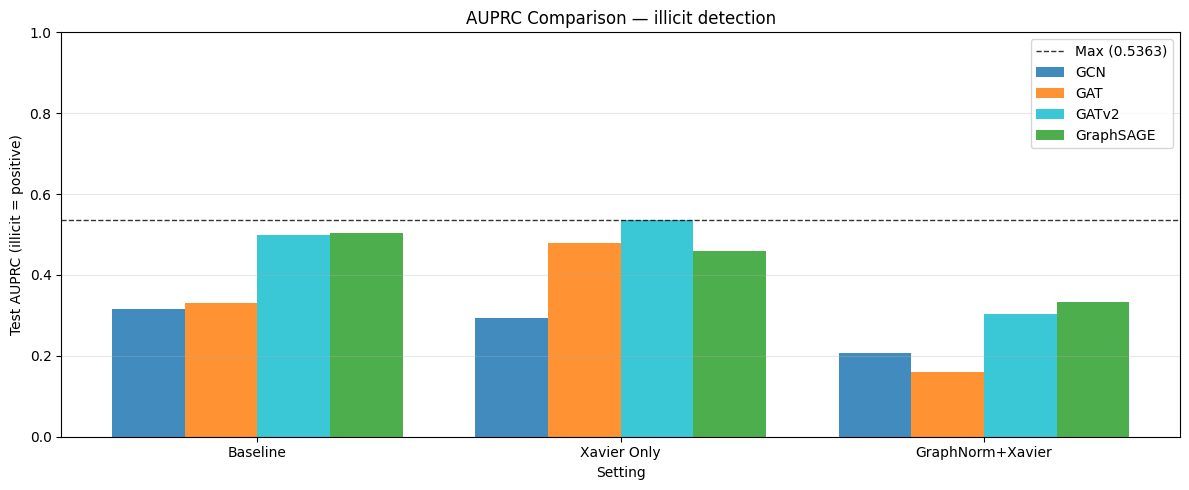

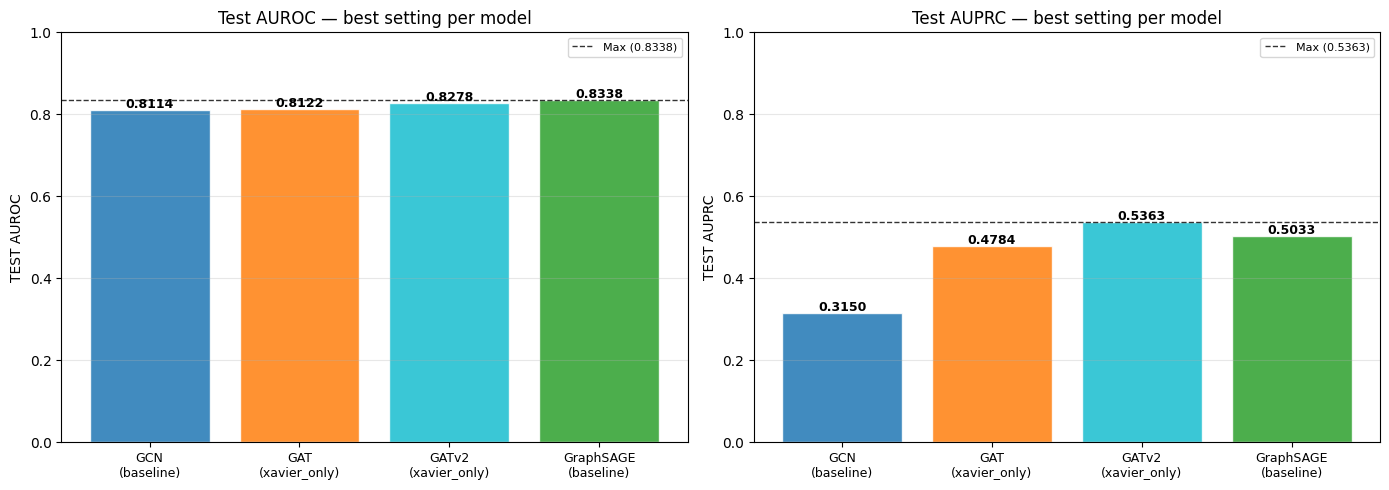

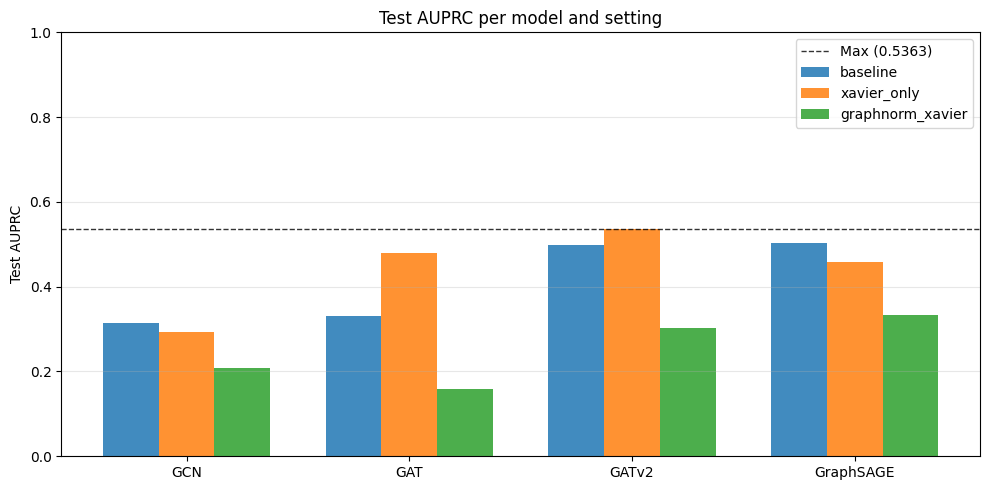

In [ ]:
# ── AUPRC bar chart (all settings per model) ─────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
x     = np.arange(len(EXPERIMENT_SETTINGS))
width = 1.0 / (len(MODEL_NAMES) + 1)
_auprc_all = [all_results.get((s, m), {}).get('test_auprc', 0)
              for s in EXPERIMENT_SETTINGS for m in MODEL_NAMES]
_auprc_max = max(_auprc_all) if _auprc_all else 0

for i, model in enumerate(MODEL_NAMES):
    vals = [all_results.get((s, model), {}).get('test_auprc', 0)
            for s in EXPERIMENT_SETTINGS]
    offset = (i - (len(MODEL_NAMES)-1)/2.0) * width
    display = 'GraphSAGE' if model == 'SAGE' else model
    ax.bar(x + offset, vals, width, label=display, color=COLORS[model], alpha=0.85)

ax.axhline(y=_auprc_max, linestyle='--', linewidth=1, alpha=0.8,
           color='black', label=f'Max ({_auprc_max:.4f})')
ax.set_xticks(x)
ax.set_xticklabels(['Baseline', 'Xavier Only', 'GraphNorm+Xavier'])
ax.set_xlabel('Setting'); ax.set_ylabel('Test AUPRC (illicit = positive)')
ax.set_title('AUPRC Comparison — illicit detection')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()


# ── Best setting per model (by test AUPRC) ────────────────────────────────────
best_settings = {}
for model in MODEL_NAMES:
    best_s, best_v = None, -1
    for s in EXPERIMENT_SETTINGS:
        key = (s, model)
        if key in all_results and all_results[key]['test_auprc'] > best_v:
            best_v = all_results[key]['test_auprc']
            best_s = s
    if best_s:
        best_settings[model] = best_s

# ── AUROC and AUPRC side by side (best setting per model) ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

_auroc_best = [all_results[(best_settings[m], m)]['test_auroc']
               for m in MODEL_NAMES if m in best_settings]
_auprc_best = [all_results[(best_settings[m], m)]['test_auprc']
               for m in MODEL_NAMES if m in best_settings]

for ax, metric, vals_all, title in [
    (axes[0], 'test_auroc', _auroc_best, 'Test AUROC — best setting per model'),
    (axes[1], 'test_auprc', _auprc_best, 'Test AUPRC — best setting per model'),
]:
    _max_val = max(vals_all) if vals_all else 0
    vals   = []
    labels = []
    colors = []
    for model in MODEL_NAMES:
        if model not in best_settings:
            continue
        key = (best_settings[model], model)
        vals.append(all_results[key][metric])
        display = 'GraphSAGE' if model == 'SAGE' else model
        labels.append(f'{display}\n({best_settings[model]})')
        colors.append(COLORS[model])
    bars = ax.bar(range(len(vals)), vals, color=colors, alpha=0.85,
                  edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
    ax.axhline(y=_max_val, linestyle='--', linewidth=1, alpha=0.8,
               color='black', label=f'Max ({_max_val:.4f})')
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel(metric.replace('_', ' ').upper())
    ax.set_title(title)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


# ── Test AUPRC per model per setting ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

x     = np.arange(len(MODEL_NAMES))
width = 0.25
_auprc_per = [all_results.get((s, m), {}).get('test_auprc', 0)
              for s in EXPERIMENT_SETTINGS for m in MODEL_NAMES]
_auprc_per_max = max(_auprc_per) if _auprc_per else 0

for j, setting in enumerate(EXPERIMENT_SETTINGS):
    vals = [all_results.get((setting, m), {}).get('test_auprc', 0)
            for m in MODEL_NAMES]
    ax.bar(x + (j - 1) * width, vals, width, label=setting, alpha=0.85)

ax.axhline(y=_auprc_per_max, linestyle='--', linewidth=1, alpha=0.8,
           color='black', label=f'Max ({_auprc_per_max:.4f})')
display_names = ['GraphSAGE' if m == 'SAGE' else m for m in MODEL_NAMES]
ax.set_xticks(x)
ax.set_xticklabels(display_names)
ax.set_title('Test AUPRC per model and setting')
ax.set_ylabel('Test AUPRC')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()


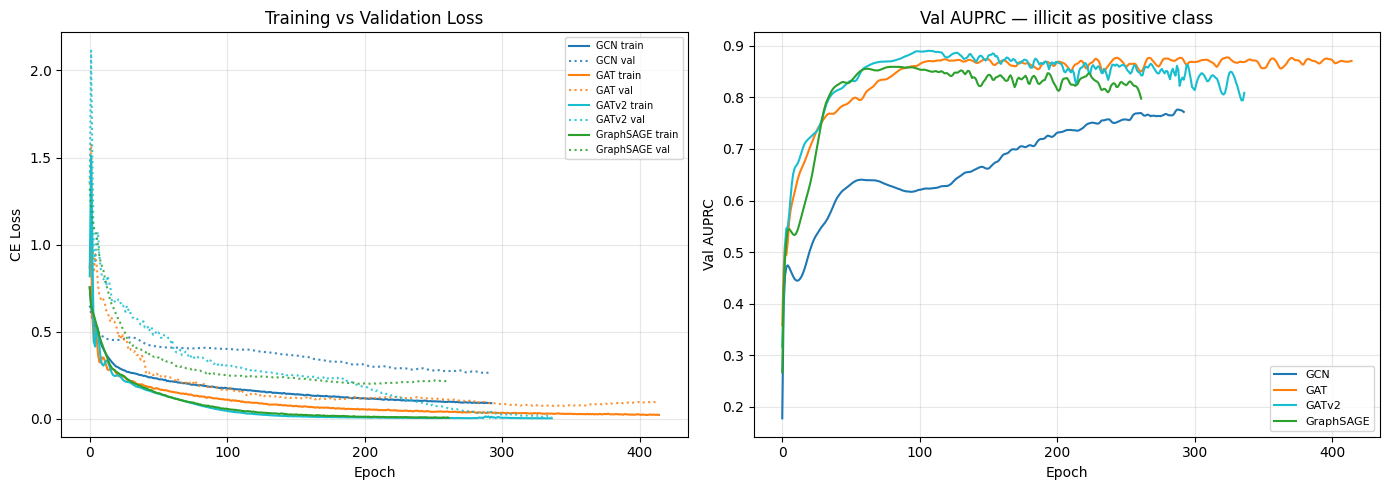

In [ ]:
# ── Best setting per model (by test AUPRC) ──────────────────────────────────
best_settings = {}
for model in MODEL_NAMES:
    best_s, best_v = None, -1
    for s in EXPERIMENT_SETTINGS:
        key = (s, model)
        if key in all_results and all_results[key]['test_auprc'] > best_v:
            best_v = all_results[key]['test_auprc']
            best_s = s
    if best_s: best_settings[model] = best_s

# ── Collect train/val loss and val AUPRC into independent dicts ──────────────
plot_train_losses = {}   # model -> list of floats (one per epoch)
plot_val_losses   = {}   # model -> list of (epoch_idx, float) tuples
plot_val_auprc    = {}   # model -> list of (epoch_idx, float) tuples

for model in MODEL_NAMES:
    if model not in best_settings:
        continue
    res = all_results[(best_settings[model], model)]

    # train losses — one value per epoch, always present
    tl = res.get('train_losses', [])
    if tl:
        plot_train_losses[model] = list(tl)

    # val losses — parallel list, None on epochs where val wasn't run
    vl = res.get('val_losses', [])
    vl_pairs = [(e, v) for e, v in enumerate(vl) if v is not None]
    if vl_pairs:
        plot_val_losses[model] = vl_pairs

    # val AUPRC — parallel list, None on epochs where val wasn't run
    vs = res.get('val_scores', [])
    vs_pairs = [(e, v) for e, v in enumerate(vs) if v is not None]
    if vs_pairs:
        plot_val_auprc[model] = vs_pairs

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for model in MODEL_NAMES:
    color   = COLORS[model]
    display = 'GraphSAGE' if model == 'SAGE' else model

    # Left: train loss (solid)
    if model in plot_train_losses:
        tl = plot_train_losses[model]
        ax1.plot(range(len(tl)), tl,
                 label=f'{display} train', color=color,
                 linewidth=1.5, linestyle='-')

    # Left: val loss (dotted, same colour)
    if model in plot_val_losses:
        epochs, vals = zip(*plot_val_losses[model])
        ax1.plot(epochs, vals,
                 label=f'{display} val', color=color,
                 linewidth=1.5, linestyle=':', alpha=0.85)

    # Right: val AUPRC
    if model in plot_val_auprc:
        epochs, vals = zip(*plot_val_auprc[model])
        ax2.plot(epochs, vals,
                 label=display, color=color, linewidth=1.5)

ax1.set_xlabel('Epoch'); ax1.set_ylabel('CE Loss')
ax1.set_title('Training vs Validation Loss (best setting per model)')
ax1.legend(fontsize=7); ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Epoch'); ax2.set_ylabel('Val AUPRC')
ax2.set_title('Val AUPRC')
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


## Save Results

In [ ]:
# ── Save scalar metrics to CSV ───────────────────────────────────────────────
rows = []
for model in MODEL_NAMES:
    for setting in ['baseline', 'xavier_only', 'graphnorm_xavier']:
        key = (setting, model)
        if key not in all_results: continue
        r = all_results[key]
        p = r['best_params']
        rows.append({
            'Model':         model,
            'Setting':       setting,
            'Test_AUROC':    round(r['test_auroc'], 4),
            'Test_AUPRC':    round(r['test_auprc'], 4),
            'Val_AUPRC':     round(r['val_auprc'],  4),
            'F1_at_90':      round(r['f1_at_90'],   4),
            'F1_at_99':      round(r['f1_at_99'],   4),
            'F1_at_99.9':    round(r.get('f1_at_99.9', 0), 4),
            'Prec_at_90':    round(r['precision_at_90'], 4),
            'Rec_at_90':     round(r['recall_at_90'],    4),
            'LR':            round(p.get('lr', 0), 8),
            'Hidden_dim':    p.get('hidden_dim'),
            'Emb_dim':       p.get('embedding_dim'),
            'Num_layers':    p.get('num_layers'),
            'Dropout':       round(p.get('dropout', 0), 5),
            'N_epochs':      p.get('n_epochs'),
            'Weight_decay':  round(p.get('weight_decay', 0), 7),
            'Aggregator':    p.get('aggregator', '-'),
        })

df = pd.DataFrame(rows)
df.to_csv('results_csv/all_results.csv', index=False)
print(f'Saved {len(rows)} rows to results_csv/all_results.csv')
print(df.to_string(index=False))

# ── Save full results dict (includes curve arrays) ────────────────────────────
with open('results_csv/all_results.pkl', 'wb') as f:
    pickle.dump(all_results, f)
print('\nFull results (curve arrays, per-epoch history) saved to results_csv/all_results.pkl')


Saved 12 rows to results_csv/all_results.csv
Model          Setting  Test_AUROC  Test_AUPRC  Val_AUPRC  F1_at_90  F1_at_99  F1_at_99.9  Prec_at_90  Rec_at_90       LR  Hidden_dim  Emb_dim  Num_layers  Dropout  N_epochs  Weight_decay Aggregator
  GCN         baseline      0.8114      0.3150     0.7762    0.3897    0.1070      0.0062      0.3056     0.5377 0.000996         166      100           2  0.42353       293      0.001630          -
  GCN      xavier_only      0.8144      0.2924     0.7821    0.3772    0.0989      0.0000      0.2958     0.5204 0.000606         196      100           2  0.09522       456      0.000028          -
  GCN graphnorm_xavier      0.7479      0.2074     0.5551    0.3499    0.0320      0.0084      0.2744     0.4827 0.000942         197      109           2  0.10091       178      0.000858          -
  GAT         baseline      0.7929      0.3303     0.8721    0.4057    0.1578      0.0031      0.3181     0.5597 0.000947         189      109           3  0.4